# LAB WORK 2 - Task 2: Developing a simple Recommender engine using KNearestNeighbors 

## Subtask A - Print the userID and movieID rating matrix

#### Opening and analysis of the datasets

In [6]:
import pandas as pd

#openeing the two datasets using pandas to better handle the data
ratings = pd.read_csv("UserID-rating 2.csv", sep=";")
movies = pd.read_csv("moviesId-title-1.cvs.csv", sep=";")

#First overview of what the titles of the datasets are
print(ratings.columns)
print(ratings.shape)

print(movies.columns)
print(movies.shape)

Index(['UserID', 'MovieID', 'rating'], dtype='str')
(310, 3)
Index(['Title', 'movieId'], dtype='str')
(31, 2)


In [7]:
#Visualizing both datasets 
print(ratings)
print()
print(movies)

     UserID  MovieID  rating
0         0        0       3
1         0        1       0
2         0        2       1
3         0        3       5
4         0        4       4
..      ...      ...     ...
305       9       26       1
306       9       27       1
307       9       28       2
308       9       29       3
309       9       30       4

[310 rows x 3 columns]

                                  Title  movieId
0   Tyler Perry's Why Did I get Married        0
1               Twilight: Breaking Dawn        1
2                              Twilight        2
3                        The Ugly Truth        3
4              The Time Traveler's Wife        4
5                          The Proposal        5
6                The Invention of Lying        6
7                    The Heartbreak Kid        7
8                           The Duchess        8
9   The Curious Case of Benjamin Button        9
10                     The Back-up Plan       10
11                              Tangled

#### Display of the userID & movieID rating matrix

In [8]:
matrix = ratings.pivot(index="MovieID", columns="UserID", values="rating").fillna(0)
#print(matrix.head())
matrix

UserID,0,1,2,3,4,5,6,7,8,9
MovieID,,,,,,,,,,
0,3,5,1,2,5,1,4,1,5,1
1,0,4,1,1,5,2,3,1,5,2
2,1,3,1,0,5,3,4,1,5,3
3,5,2,5,4,1,4,1,1,4,4
4,4,11,5,4,1,5,1,0,4,5
5,2,2,4,4,1,4,1,0,4,55
6,5,3,4,4,1,3,0,0,1,5
7,0,4,2,2,1,2,0,3,2,5
8,2,5,2,2,1,1,0,3,3,4


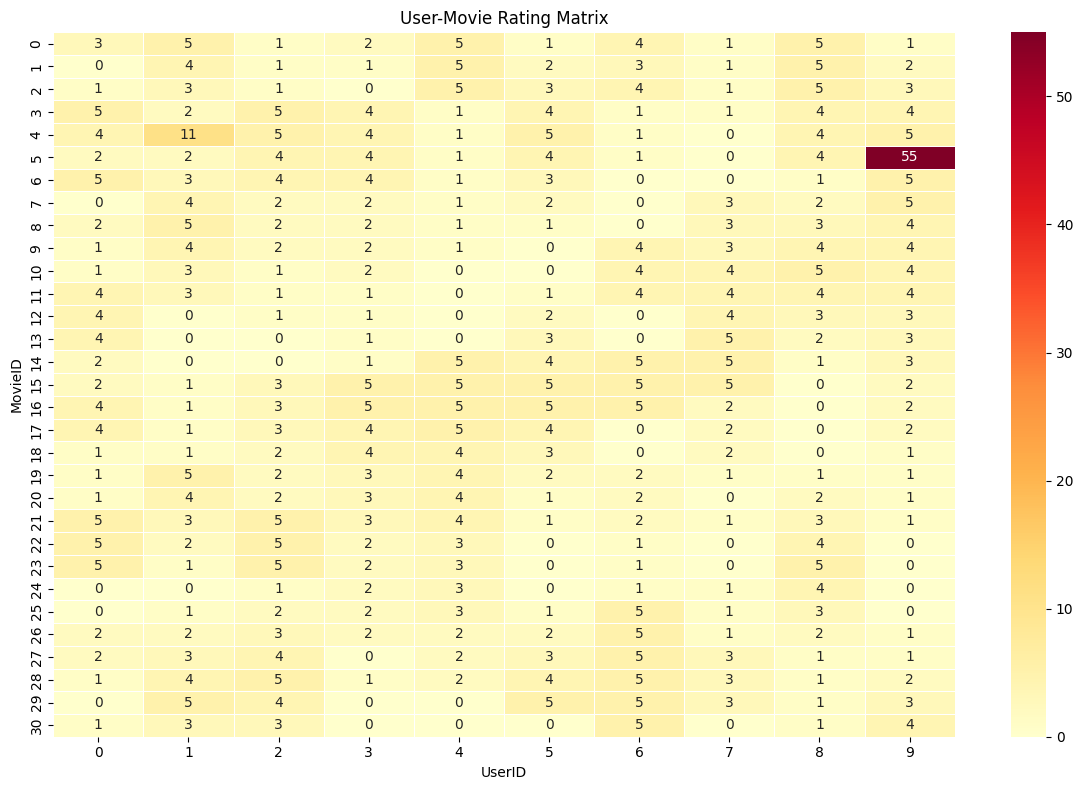

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(matrix, 
            annot=True,        # show the numbers inside cells
            fmt=".0f",         # no decimal places
            cmap="YlOrRd",     # color scale: yellow = low, red = high
            linewidths=0.5)    # grid lines between cells

plt.title("User-Movie Rating Matrix")
plt.xlabel("UserID")
plt.ylabel("MovieID")
plt.tight_layout()
plt.show()

## Subtask B - Program a movie recommender system using KNnearestNeighbors-Algorithm

We have used the provided learning materials in the task description, namely the sklearn neighbors module and the lecture slides of Pr. R. Jaeger to understand what to do and the way to do it for our specific task.

We separated the implementation in two parts : Euclidean Distance and Manhattan distance.

#### Using Euclidean Metric

In [ ]:
from sklearn.neighbors import NearestNeighbors

#We initialise the NearestNeighbors model to the knn_algo_eu and specify the euclidean metric 
#and brute algorithm : compare the one movie with all the others by computing the euclidean distances and comparing which is the highest values
knn_algo_eu = NearestNeighbors(metric="euclidean", algorithm="brute")

#fit the NearestNieghbors model to our dataset
knn_algo_eu.fit(matrix)

#query_eu=1
movie_name0 = input("QUERY : Please enter your movie title : ")
query_eu = movies[movies["Title"] == movie_name0]["movieId"].values[0]

distances_eu, indexes_eu = knn_algo_eu.kneighbors(matrix.iloc[query_eu,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix.index[query_eu]}, {movie_name0}, are :")
print()
for i in range(1, len(distances_eu.flatten())):
    movie_eu_idx = matrix.index[indexes_eu.flatten()[i]]
    title = movies[movies["movieId"] == movie_eu_idx]["Title"].values[0]
    distance_eu = distances_eu.flatten()[i]
    print(f'recommended movie {movie_eu_idx}, {title}, with a Euclidean distance of {distance_eu}')

The Recommendations for movie 2, Twilight, are :

recommended movie 1, Twilight: Breaking Dawn, with a Euclidean distance of 2.449489742783178
recommended movie 0, Tyler Perry's Why Did I get Married, with a Euclidean distance of 4.47213595499958
recommended movie 25, It's Complicated, with a Euclidean distance of 5.656854249492381
recommended movie 20, New Years Eve, with a Euclidean distance of 5.830951894845301
recommended movie 26, Fireproof, with a Euclidean distance of 5.830951894845301


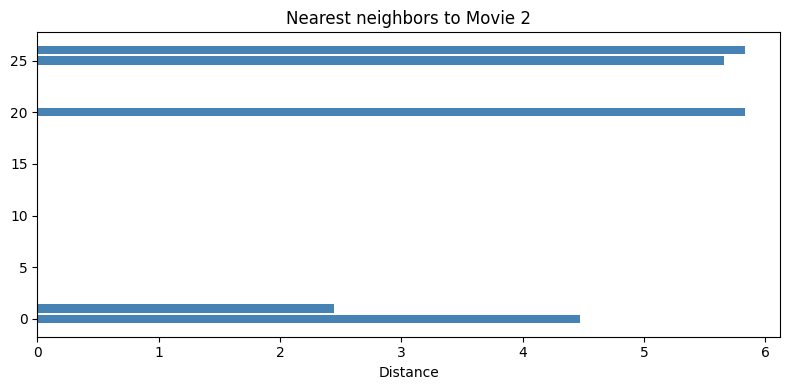

In [14]:
query_movie = matrix.index[query_eu]
neighbor_movies = [matrix.index[indexes_eu.flatten()[i]] for i in range(len(distances_eu.flatten()))]
neighbor_distances = distances_eu.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

#### Using Manhattan Metric

In [15]:
knn_algo_man = NearestNeighbors(metric="manhattan", algorithm="brute")

knn_algo_man.fit(matrix)

#query_man=1
movie_name1 = input("QUERY : Please enter your movie title : ")
query_man = movies[movies["Title"] == movie_name1]["movieId"].values[0]

distances_man, indexes_man = knn_algo_man.kneighbors(matrix.iloc[query_man,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix.index[query_man]}, {movie_name1}, are :")
print()
for i in range(1, len(distances_man.flatten())):
    movie_man_idx = matrix.index[indexes_man.flatten()[i]]
    title = movies[movies["movieId"] == movie_man_idx]["Title"].values[0]
    distance_man = distances_man.flatten()[i]
    print(f'recommended movie {movie_man_idx}, {title}, with a Manhattan distance of {distance_man}')

The Recommendations for movie 2, Twilight, are :

recommended movie 1, Twilight: Breaking Dawn, with a Manhattan distance of 6.0
recommended movie 0, Tyler Perry's Why Did I get Married, with a Manhattan distance of 10.0
recommended movie 10, The Back-up Plan, with a Manhattan distance of 14.0
recommended movie 9, The Curious Case of Benjamin Button, with a Manhattan distance of 15.0
recommended movie 11, Tangled, with a Manhattan distance of 16.0


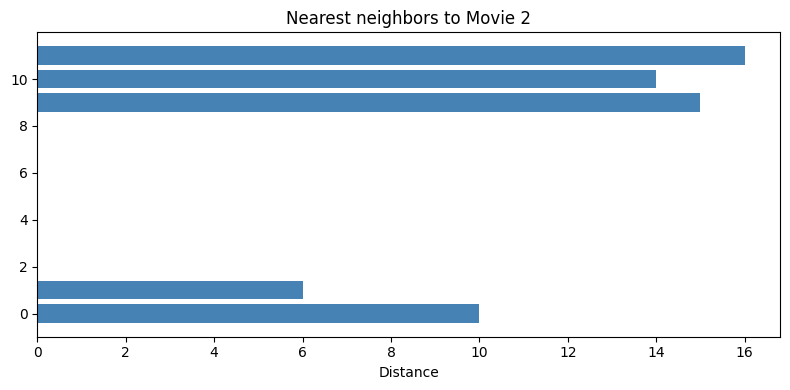

In [16]:
query_movie = matrix.index[query_man]
neighbor_movies = [matrix.index[indexes_man.flatten()[i]] for i in range(len(distances_man.flatten()))]
neighbor_distances = distances_man.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

## Using PREPROCESSING (Changing the assumed typos into their corresponding values)

In [17]:
ratings_fixed = ratings.copy()
ratings_fixed["rating"] = ratings_fixed["rating"].replace({11: 1, 55: 5})
matrix_fixed = ratings_fixed.pivot(index="MovieID", columns="UserID", values="rating").fillna(0)
matrix_fixed

UserID,0,1,2,3,4,5,6,7,8,9
MovieID,,,,,,,,,,
0,3,5,1,2,5,1,4,1,5,1
1,0,4,1,1,5,2,3,1,5,2
2,1,3,1,0,5,3,4,1,5,3
3,5,2,5,4,1,4,1,1,4,4
4,4,1,5,4,1,5,1,0,4,5
5,2,2,4,4,1,4,1,0,4,5
6,5,3,4,4,1,3,0,0,1,5
7,0,4,2,2,1,2,0,3,2,5
8,2,5,2,2,1,1,0,3,3,4


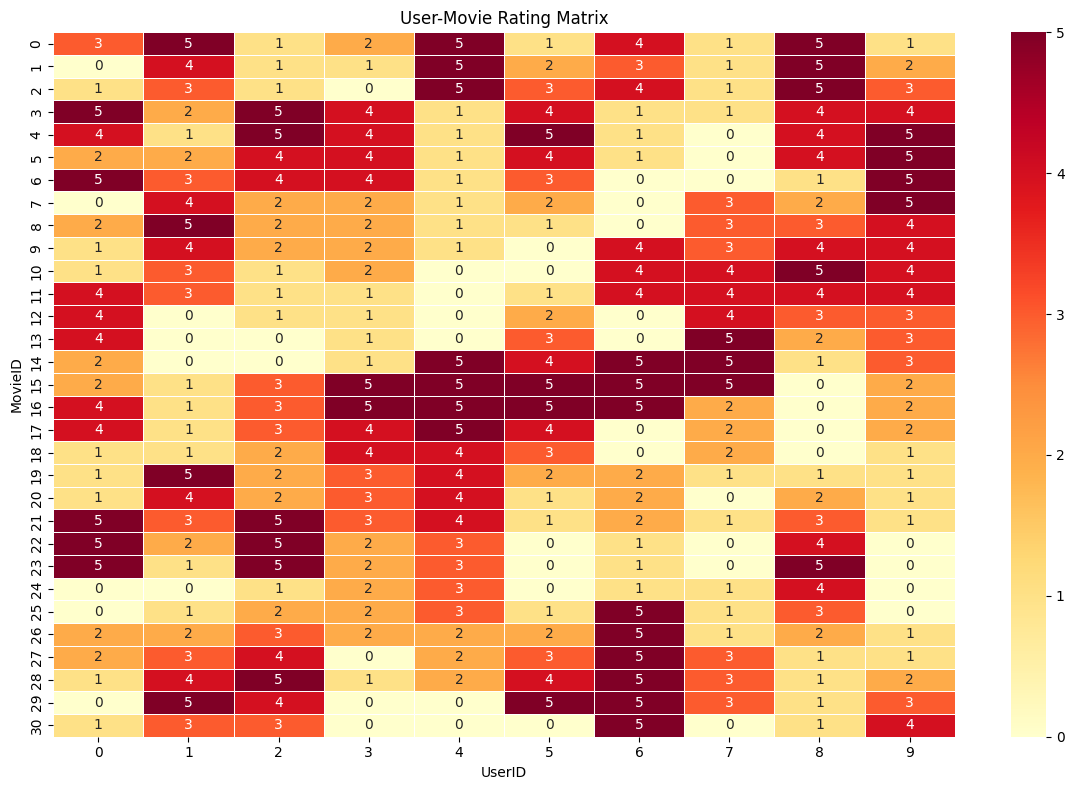

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(matrix_fixed, 
            annot=True,        # show the numbers inside cells
            fmt=".0f",         # no decimal places
            cmap="YlOrRd",     # color scale: yellow = low, red = high
            linewidths=0.5)    # grid lines between cells

plt.title("User-Movie Rating Matrix")
plt.xlabel("UserID")
plt.ylabel("MovieID")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

#We initialise the NearestNeighbors model to the knn_algo_eu and specify the euclidean metric 
#and brute algorithm : compare the one movie with all the others by computing the euclidean distances and comparing which is the highest values
knn_algo_eu_fixed = NearestNeighbors(metric="euclidean", algorithm="brute")

#fit the NearestNieghbors model to our dataset
knn_algo_eu_fixed.fit(matrix_fixed)

#query_eu=1
movie_name0_fixed = input("QUERY : Please enter your movie title : ")
query_eu_fixed = movies[movies["Title"] == movie_name0_fixed]["movieId"].values[0]

distances_eu_fixed, indexes_eu_fixed = knn_algo_eu_fixed.kneighbors(matrix_fixed.iloc[query_eu_fixed,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_eu_fixed]}, {movie_name0_fixed}, are :")
print()
for i in range(1, len(distances_eu_fixed.flatten())):
    movie_eu_idx_fixed = matrix_fixed.index[indexes_eu_fixed.flatten()[i]]
    title_fixed = movies[movies["movieId"] == movie_eu_idx_fixed]["Title"].values[0]
    distance_eu_fixed = distances_eu_fixed.flatten()[i]
    print(f'recommended movie {movie_eu_idx_fixed}, {title_fixed}, with a Euclidean distance of {distance_eu_fixed}')

The Recommendations for movie 2, Twilight, are :

recommended movie 1, Twilight: Breaking Dawn, with a Euclidean distance of 2.449489742783178
recommended movie 0, Tyler Perry's Why Did I get Married, with a Euclidean distance of 4.47213595499958
recommended movie 25, It's Complicated, with a Euclidean distance of 5.656854249492381
recommended movie 20, New Years Eve, with a Euclidean distance of 5.830951894845301
recommended movie 26, Fireproof, with a Euclidean distance of 5.830951894845301


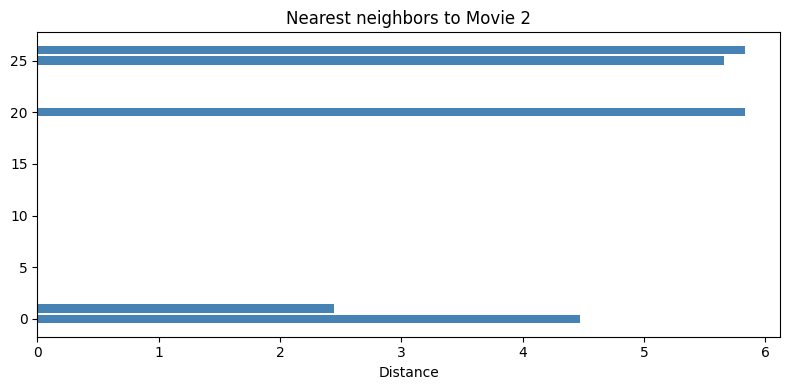

In [21]:
query_movie = matrix_fixed.index[query_eu_fixed]
neighbor_movies = [matrix_fixed.index[indexes_eu_fixed.flatten()[i]] for i in range(len(distances_eu_fixed.flatten()))]
neighbor_distances = distances_eu_fixed.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

In [22]:
knn_algo_man_fixed = NearestNeighbors(metric="manhattan", algorithm="brute")

knn_algo_man_fixed.fit(matrix_fixed)

#query_man=1
movie_name1_fixed = input("QUERY : Please enter your movie title : ")
query_man_fixed = movies[movies["Title"] == movie_name1_fixed]["movieId"].values[0]

distances_man_fixed, indexes_man_fixed = knn_algo_man_fixed.kneighbors(matrix_fixed.iloc[query_man_fixed,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_man_fixed]}, {movie_name1_fixed}, are :")
print()
for i in range(1, len(distances_man_fixed.flatten())):
    movie_man_idx_fixed = matrix_fixed.index[indexes_man_fixed.flatten()[i]]
    title_fixed = movies[movies["movieId"] == movie_man_idx_fixed]["Title"].values[0]
    distance_man_fixed = distances_man_fixed.flatten()[i]
    print(f'recommended movie {movie_man_idx_fixed}, {title_fixed}, with a Manhattan distance of {distance_man_fixed}')

The Recommendations for movie 2, Twilight, are :

recommended movie 1, Twilight: Breaking Dawn, with a Manhattan distance of 6.0
recommended movie 0, Tyler Perry's Why Did I get Married, with a Manhattan distance of 10.0
recommended movie 10, The Back-up Plan, with a Manhattan distance of 14.0
recommended movie 9, The Curious Case of Benjamin Button, with a Manhattan distance of 15.0
recommended movie 11, Tangled, with a Manhattan distance of 16.0


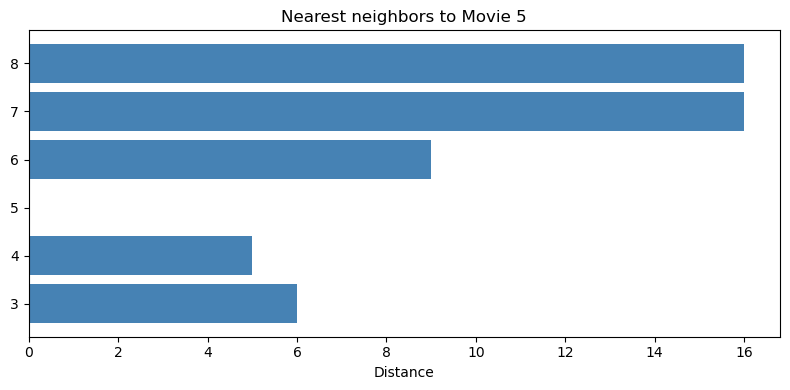

In [23]:
query_movie = matrix.index[query_man_fixed]
neighbor_movies = [matrix_fixed.index[indexes_man_fixed.flatten()[i]] for i in range(len(distances_man_fixed.flatten()))]
neighbor_distances = distances_man_fixed.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

## Subtask C - One real Test Case : The Duchess

For this subtask we choose the movie **"The Duchess"** as our query movie to test the recommender system. We want to find the 5 closest movies to it using both the Euclidean and Manhattan distance metric, so we can see if the recommendations makes sense. We use the preprocessed matrix (with the typos corrected) for this test.

#### Euclidean Distance - The Duchess

In [23]:
# test case : we fix the query movie to The Duchess (movieId = 8)
movie_name_duchess = "The Duchess"
query_duchess = movies[movies["Title"] == movie_name_duchess]["movieId"].values[0]

# we reuse the knn model already fitted on matrix_fixed
distances_duchess_eu, indexes_duchess_eu = knn_algo_eu_fixed.kneighbors(
    matrix_fixed.iloc[query_duchess,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_duchess]}, {movie_name_duchess}, are :")
print()
for i in range(1, len(distances_duchess_eu.flatten())):
    movie_eu_idx = matrix_fixed.index[indexes_duchess_eu.flatten()[i]]
    title = movies[movies["movieId"] == movie_eu_idx]["Title"].values[0]
    dist = distances_duchess_eu.flatten()[i]
    print(f'recommended movie {movie_eu_idx}, {title}, with a Euclidean distance of {dist}')

The Recommendations for movie 8, The Duchess, are :

recommended movie 7, The Heartbreak Kid, with a Euclidean distance of 2.8284271247461903
recommended movie 9, The Curious Case of Benjamin Button, with a Euclidean distance of 4.47213595499958
recommended movie 10, The Back-up Plan, with a Euclidean distance of 5.385164807134504
recommended movie 11, Tangled, with a Euclidean distance of 5.385164807134504
recommended movie 19, Not Easily Broken, with a Euclidean distance of 5.744562646538029


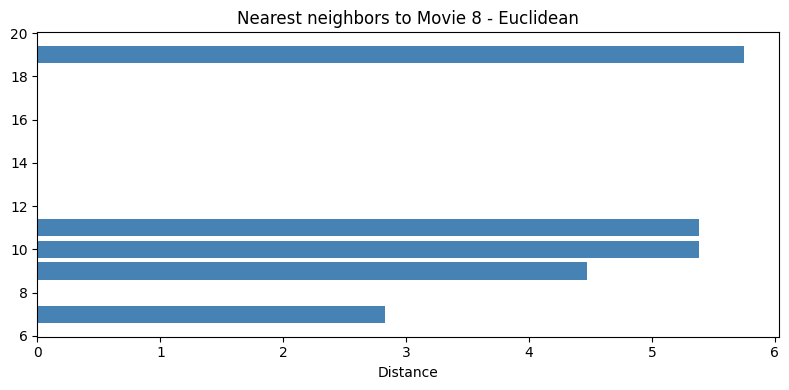

In [24]:
query_movie_d = matrix_fixed.index[query_duchess]
neighbor_movies_d_eu = [matrix_fixed.index[indexes_duchess_eu.flatten()[i]] for i in range(len(distances_duchess_eu.flatten()))]
neighbor_distances_d_eu = distances_duchess_eu.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies_d_eu[1:], neighbor_distances_d_eu[1:], color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie_d} - Euclidean")
plt.tight_layout()
plt.show()

#### Manhattan Distance - The Duchess

In [25]:
# same test but now with manhattan metric
distances_duchess_man, indexes_duchess_man = knn_algo_man_fixed.kneighbors(
    matrix_fixed.iloc[query_duchess,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_duchess]}, {movie_name_duchess}, are :")
print()
for i in range(1, len(distances_duchess_man.flatten())):
    movie_man_idx = matrix_fixed.index[indexes_duchess_man.flatten()[i]]
    title = movies[movies["movieId"] == movie_man_idx]["Title"].values[0]
    dist = distances_duchess_man.flatten()[i]
    print(f'recommended movie {movie_man_idx}, {title}, with a Manhattan distance of {dist}')

The Recommendations for movie 8, The Duchess, are :

recommended movie 7, The Heartbreak Kid, with a Manhattan distance of 6.0
recommended movie 9, The Curious Case of Benjamin Button, with a Manhattan distance of 8.0
recommended movie 10, The Back-up Plan, with a Manhattan distance of 13.0
recommended movie 11, Tangled, with a Manhattan distance of 13.0
recommended movie 12, Something Borrowed, with a Manhattan distance of 13.0


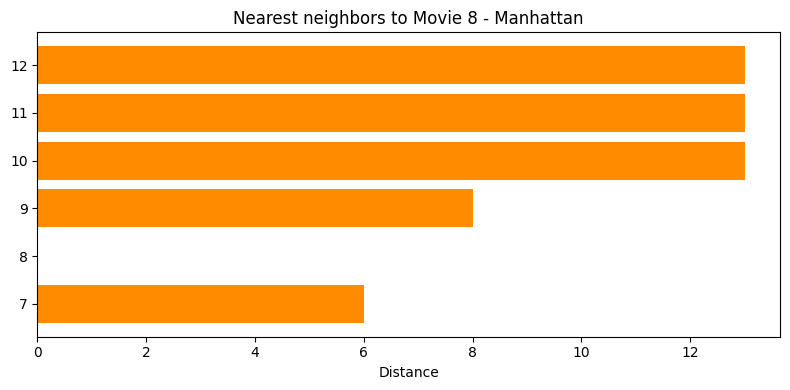

In [26]:
neighbor_movies_d_man = [matrix_fixed.index[indexes_duchess_man.flatten()[i]] for i in range(len(distances_duchess_man.flatten()))]
neighbor_distances_d_man = distances_duchess_man.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies_d_man[1:], neighbor_distances_d_man[1:], color="darkorange")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie_d} - Manhattan")
plt.tight_layout()
plt.show()

## Subtask D - Comparing the two metrics

After running the recommender system for the movie **"The Duchess"** with both the Euclidean and the Manhattan distance, we can make some observations about the differences between the two metrics.

**About the recommended movies :**

Looking at the results we can see that both metrics gives mostly the same movies in the top 5, but the order can be slightly different. This is not a suprise because both are distance-based metrics and they measure similary the same thing, just with a different formula. For this small dataset with only 10 users the differences are not very big.

**About the distances values :**

One clear difference is that the Manhattan distances are always bigger numbers than the Euclidean ones. This is because Manhattan sums the absolute differences of all the dimensions directly, while Euclidean first squares them, then sums and then takes the square root. So for same pair of movies the Manhattan distance will always be equal or bigger then the Euclidean distance (this is a mathematical property of the two metrics).

**Which metric is better here ?**

From the lecture we know that Euclidean distance gives more weight to big differences between ratings because of the squaring. So if one user gave very different rating for two movies, Euclidean will penalize this more. Manhattan on the other side treat all dimensions equally and is more robust to outliers. For our dataset which is quite small and has ratings from 0 to 5, both metrics seems to work fine and give reasonable recommendations. In a bigger dataset the choice of metric could have more impact on the results.